# Plot results for offline prompting in the "dragon" example

In [1]:
%cd ..
%pwd  # should be "llm-adaptation"

C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation


C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


'C:\\Users\\micha\\OneDrive - Univerzita Karlova\\research\\2024-LLM-DEECo\\llm-adaptation'

In [104]:
from pathlib import Path
import pandas as pd
import shutil
import subprocess
import sys
import json
import matplotlib.pyplot as plt
from matplotlib.markers import MarkerStyle
import numpy as np

In [3]:
results_folder = Path("generated_adaptations/dragon")
pd.options.display.float_format = "{:,.1f}".format

## Run experiments

In [34]:
prompt = "generated_adaptations/prompts/dragon_strategy.md"
variants = {
    "default": [],
    "notest": ["--retries_test=0"],
    "constraints": []
}
llms = {
    # "5nanolow": "gpt-5-nano-2025-08-07,reasoning_effort=low",
    # "5nano": "gpt-5-nano-2025-08-07",
    "5mini": "gpt-5-mini-2025-08-07",
    # "5": "gpt-5-2025-08-07",
}
repeats = 3
start = 1

In [35]:
# import generated_adaptations.generator as generator

In [36]:
for variant, args in variants.items():
    for llm_name, llm in llms.items():
        for repeat in range(start, start + repeats):
            folder_name = f"{llm_name}_{repeat:02d}"
            print(f"\n{variant}/{folder_name}\n")
            folder = results_folder / variant / folder_name
            folder.mkdir(parents=True, exist_ok=True)
            shutil.copy(prompt, folder / "01_01_user.md")
            cmd  = [sys.executable, "generated_adaptations/generator.py", f"--folder={str(folder)}", f"--llm={llm}", *args]
            result = subprocess.run(cmd, capture_output=True, text=True)  # even capture_output=False does not stream in real-time, so we rather capture it and print it later
            print(result.stdout)
            print(result.stderr)
            # generator.main([f"--folder={str(folder)}"])  # this also does not show the real-time output


default/5mini_01

Loaded 2 messages from generated_adaptations\dragon\default\5mini_01.
Querying LLM with prompt 01_01_user.
LLM response saved to '01_02_llm.md'.
Code block saved to 'generated_adaptations\dragon\default\5mini_01\code_01_02.py'.
TOKENS USED:
Input: 1066, Output: 3721 (reasoning: 1984)
Response time (seconds): 57.2

Running tests: pytest generated_adaptations/tests -q --tb=short -rfExXpP --show-capture=no --color=no --example=dragon --adaptation_name=5mini_01/code_01_02 --variant=default
Test exit code: 0
Running simulation for 'generated_adaptations\dragon\default\5mini_01\code_01_02.py'.
  Run #1/3: python main.py dragon/configs/default.yaml generated_adaptations/configs/generated.yaml DSL/dragon.yaml --extra_config={"name": "default/5mini_01/code_01_02", "log_dir.append": "/default/5mini_01/code_01_02", "adaptation_name": "generated_adaptations.dragon.default.5mini_01.code_01_02.SmartAdaptation"} -s 1 -e 1
  Run #2/3: python main.py dragon/configs/default.yaml gener

## Results

In [123]:
folders = list(results_folder.glob("*/*"))
# folders = list(results_folder.glob("*/5nano_*"))
# folders = list(results_folder.glob("*/5nanolow*"))
# folders = [results_folder / "41mini"]
print([(f.parent.stem, f.stem) for f in folders])

[('constraints', '5nanolow_01'), ('result', '5nanolow_01'), ('stats', '5nanolow_01'), ('system', '5nanolow_01')]


In [124]:
summary = pd.DataFrame(columns=["llm", "params", "repeat"])

for folder in folders:
    llm, repeat = folder.stem.split("_")
    params = folder.parent.stem
    summary.loc[len(summary), ["llm", "params", "repeat"]] = [llm, params, repeat]

    for file in (folder / "results").glob("*.txt"):
        name = file.stem.removeprefix("code_")
        code = name.split("_")[0]
        if "_missing" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "missing"
        if "_system_fail" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "fail"
        elif "_system_pass" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "pass"
        elif "_all_fail" in name:
            summary.loc[len(summary) - 1, code + "_user"] = "fail"
        elif "_all_pass" in name:
            summary.loc[len(summary) - 1, code + "_user"] = "pass"
        else:
            print(f"Unknown file: {file}")
    for file in (folder / "results").glob("*.json"):
        name = file.stem.removeprefix("code_")
        if "_simulation_result" in name:
            code = name.removesuffix("_simulation_result")
            results = json.load(open(file))
            # result = results["winrate"]
            result = results["steps"]
            if result is None:
                result = "-"
            summary.loc[len(summary) - 1, code + "_result"] = result
        else:
            print(f"Unknown file: {file}")

summary = summary.astype("object")
summary.fillna("", inplace=True)

In [125]:
summary.set_index(["llm", "params", "repeat"], inplace=True)

In [126]:
summary = summary.reindex(sorted(summary.columns), axis=1)

In [127]:
summary

02_result 02_system 02_user 04_result 04_system  \
llm      params      repeat                                                   
5nanolow constraints 01             -      fail    fail         -      pass   
         result      01             -      pass    fail         -      pass   
         stats       01             -      fail    fail         -      fail   
         system      01             -      fail    fail         -      pass   

                            04_user 06_result 06_system 06_user 08_result  \
llm      params      repeat                                                 
5nanolow constraints 01        fail         -      pass    fail         -   
         result      01        fail         -      pass    fail         -   
         stats       01        fail         -      fail    fail         -   
         system      01        fail         -      pass    fail         -   

                             ... 14_user 16_result 16_system 16_user  \
llm      params      repeat  ...                                       
5nanolow constraints 01      ...    fail         -      pass    fail   
         result      01      ...    fail         -      pass    fail   
         stats       01      ...    fail         -      fail    fail   
         system      01      ...    fail         -      pass    fail   

                            18_result 18_system 18_user 20_result 20_system  \
llm      params      repeat                                                   
5nanolow constraints 01             -      pass    fail         -      pass   
         result      01             -      pass    fail         -      pass   
         stats       01             -      fail    fail         -      fail   
         system      01          12.0      pass    pass                       

                            20_user  
llm      params      repeat          
5nanolow constraints 01        fail  
         result      01        fail  
         stats       01        fail  
         system      01              

[4 rows x 30 columns]

### Plot

In [128]:
result_cols = [col for col in summary.columns if col.endswith("_result")]
plot_data = summary[result_cols].replace({"-": 30, "": np.nan}).astype(float)
plot_data

C:\Users\micha\AppData\Local\Temp\ipykernel_4456\2552851031.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_data = summary[result_cols].replace({"-": 30, "": np.nan}).astype(float)


02_result  04_result  06_result  08_result  \
llm      params      repeat                                               
5nanolow constraints 01           30.0       30.0       30.0       30.0   
         result      01           30.0       30.0       30.0       30.0   
         stats       01           30.0       30.0       30.0       30.0   
         system      01           30.0       30.0       30.0       30.0   

                             10_result  12_result  14_result  16_result  \
llm      params      repeat                                               
5nanolow constraints 01           30.0       30.0       30.0       30.0   
         result      01           30.0       30.0       30.0       30.0   
         stats       01           30.0       30.0       30.0       30.0   
         system      01           30.0       30.0       30.0       30.0   

                             18_result  20_result  
llm      params      repeat                        
5nanolow constraints 01           30.0       30.0  
         result      01           30.0       30.0  
         stats       01           30.0       30.0  
         system      01           12.0        NaN

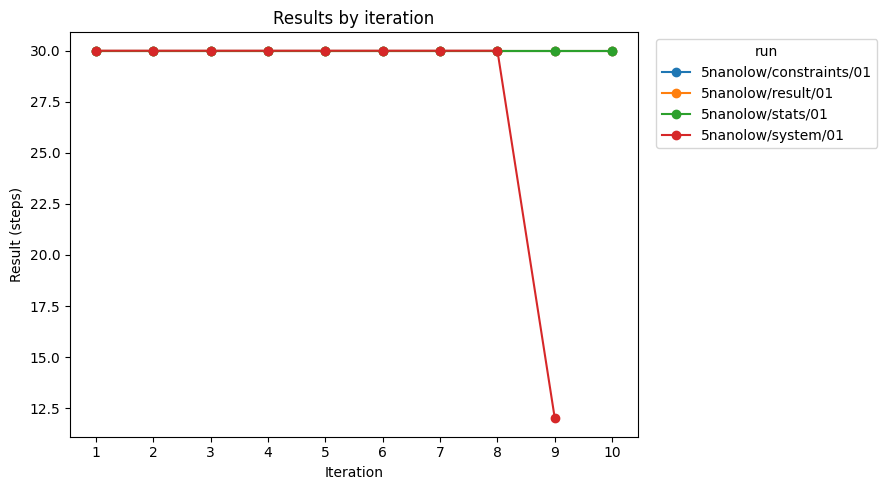

In [129]:
# transpose so columns become x axis
plot_df = plot_data.T.copy()

# turn multiindex column names (llm, params, repeat) into readable labels
plot_df.columns = [f"{llm}/{params}/{repeat}" for llm, params, repeat in plot_df.columns]

x = list(range(1, len(plot_df.index) + 1))

fig, ax = plt.subplots(figsize=(9, 5))
plot_df.plot(ax=ax, marker='o', legend=True)

# set x ticks to simple iteration numbers
ax.set_xticks(range(len(plot_df.index)))
ax.set_xticklabels(x)  # shows 1,2,3,...
ax.set_xlabel("Iteration")
ax.set_ylabel("Result (steps)")
ax.set_title("Results by iteration")
ax.legend(title="run", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

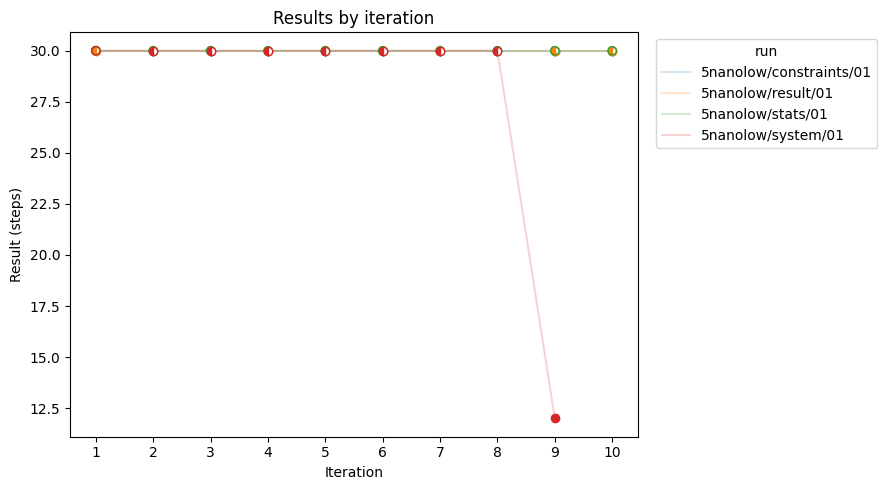

In [131]:
plot_df = plot_data.T.copy()  # index: result columns like `02_result`, columns: MultiIndex (llm, params, repeat)
orig_cols = plot_df.columns  # MultiIndex
labels = [f"{llm}/{params}/{repeat}" for llm, params, repeat in orig_cols]
x = list(range(1, len(plot_df.index) + 1))

fig, ax = plt.subplots(figsize=(9, 5))
for col, label in zip(orig_cols, labels):
    y = plot_df[col].values
    # draw the line for the run
    line, = ax.plot(x, y, '-', label=label, alpha=0.2)
    color = line.get_color()

    # collect indices by test status
    pass_idx, half_idx, fail_idx = [], [], []
    for i, result_col in enumerate(plot_df.index):  # e.g. '02_result'
        system_col = result_col.replace('_result', '_system')
        user_col = result_col.replace('_result', '_user')

        system = summary.loc[col, system_col]
        user = summary.loc[col, user_col]

        if system == "pass" and user == "pass":
            pass_idx.append(i)
        elif system == "pass":
            half_idx.append(i)
        else:
            fail_idx.append(i)

    # overplot markers (use same color as the line)
    if pass_idx:
        ax.scatter([x[i] for i in pass_idx], [y[i] for i in pass_idx], marker='o', color=color, zorder=3)
    if half_idx:
        ax.scatter([x[i] for i in half_idx], [y[i] for i in half_idx], marker=MarkerStyle("o", fillstyle="left"), color=color, zorder=3)
        ax.scatter([x[i] for i in half_idx], [y[i] for i in half_idx], marker=MarkerStyle("o", fillstyle="right"), color="white", edgecolors=color, zorder=3)
    if fail_idx:
        ax.scatter([x[i] for i in fail_idx], [y[i] for i in fail_idx], marker='o', color=color, zorder=3, facecolors='none')

# finalize axes
ax.set_xticks(x)
ax.set_xticklabels(x)  # iterations 1,2,3,...
ax.set_xlabel("Iteration")
ax.set_ylabel("Result (steps)")
ax.set_title("Results by iteration")
ax.legend(title="run", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()